# RAFT — Confusion Matrix · ROC (200개) · **로컬 노트북**

GPU / S3 없이 **PC에서 이 노트북만** 실행합니다.

## 준비
1. JSON을 `ai/docs/notebooks/data/`에 두거나, **셀 3**이 S3 / `results/infer/`에서 자동 탐색
2. **ffpp_vox 필수**, celebdf 선택 → 합산 최대 200개
3. **Kernel → Restart Kernel** 후 **Run All**
4. 패키지가 없으면 셀 3이 자동 설치합니다

| profile | 파일 | RUN_ID (참고) |
|---------|------|---------------|
| ffpp_vox | `data/raft_ffpp_vox_benchmark_report.json` | `raft-ffpp-vox-benchmark-20260622-0523` |
| celebdf (선택) | `data/raft_celebdf_benchmark_report.json` | `optical-flow-celebdf-20260619-0504` 등 |

기본 threshold **0.5** (`motion_anomaly_score` / `fake_score`).

출력 PNG: `output/raft-cm/` (`cm_raft_*_*.png`, `roc_raft_*_*.png`)

팀 CM 표기: Xception/EfficientNet/PWC-Net 노트북과 동일 (Positive = fake)


In [ ]:
# (선택) 셀 2가 자동 설치합니다.
# %pip install matplotlib seaborn scikit-learn numpy pandas


## JSON 다운로드 (최초 1회)

```powershell
$DATA = "c:\sw_study\finalpjt\ai\docs\notebooks\data"
New-Item -ItemType Directory -Force -Path $DATA | Out-Null

scp sk4team@58.127.241.84:~/forenShield-ai/results/infer/raft-ffpp-vox-benchmark-20260622-0523/benchmark_report.json "$DATA\raft_ffpp_vox_benchmark_report.json"

scp sk4team@58.127.241.84:~/forenShield-ai/results/infer/optical-flow-celebdf-20260619-0504/benchmark_report.json "$DATA\raft_celebdf_benchmark_report.json"
```

S3:
- `cases/test/video-benchmark-datasets/raft/ffpp_vox/benchmark_report.json`
- `cases/test/video-benchmark-datasets/raft/celebdf/benchmark_report.json` (또는 optical-flow 벤치마크 경로)


In [8]:
import json
import subprocess
import sys
from pathlib import Path


def _ensure_pkg(import_name: str, pip_name: str | None = None) -> None:
    pip_name = pip_name or import_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {pip_name} into {sys.executable} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


for _mod, _pip in [
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
]:
    _ensure_pkg(_mod, _pip)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib as mpl
import matplotlib.font_manager as fm

print("packages OK")


def _setup_korean_font() -> str:
    candidates = [
        "Malgun Gothic",
        "NanumGothic",
        "Nanum Gothic",
        "AppleGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return "default"


_kr_font = _setup_korean_font()
print(f"matplotlib font: {_kr_font}")

# 노트북 위치 기준 경로 (하드코드 대신 자동 탐색)
_cwd = Path.cwd().resolve()
if (_cwd / "data").is_dir():
    NOTEBOOK_DIR = _cwd
elif (_cwd.parent / "data").is_dir():
    NOTEBOOK_DIR = _cwd.parent
else:
    NOTEBOOK_DIR = Path(r"c:\sw_study\finalpjt\ai\docs\notebooks")
AI_ROOT = NOTEBOOK_DIR.parent.parent

DATA_DIR = NOTEBOOK_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_FILES = {
    "ffpp_vox": DATA_DIR / "raft_ffpp_vox_benchmark_report.json",
    "celebdf": DATA_DIR / "raft_celebdf_benchmark_report.json",
}

S3_BUCKET = "s3://forenshield-evidence-877044078824"
S3_CANDIDATES: dict[str, list[str]] = {
    "ffpp_vox": [
        f"{S3_BUCKET}/cases/test/video-benchmark-datasets/raft/ffpp_vox/benchmark_report.json",
        f"{S3_BUCKET}/cases/test/video-benchmark-datasets/RAFT/ffpp_vox/benchmark_report.json",
        f"{S3_BUCKET}/cases/test/video-optical-flow-benchmark/reports/raft-ffpp-vox-benchmark-20260622-0523/benchmark_report.json",
    ],
    "celebdf": [
        f"{S3_BUCKET}/cases/test/video-benchmark-datasets/raft/celebdf/benchmark_report.json",
        f"{S3_BUCKET}/cases/test/video-benchmark-datasets/RAFT/celebdf/benchmark_report.json",
        f"{S3_BUCKET}/cases/test/video-optical-flow-benchmark/reports/optical-flow-celebdf-20260619-0504/benchmark_report.json",
    ],
}

PROFILE_HINTS = {
    "ffpp_vox": ("ffpp_vox", "ffpp-vox", "ffpp_vox"),
    "celebdf": ("celebdf", "celeb-df", "celeb_df"),
}

THRESHOLDS = {
    "ffpp_vox": 0.5,
    "celebdf": 0.5,
}

OUT_DIR = NOTEBOOK_DIR / "output" / "raft-cm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_TEAM = ["fake", "real"]


def _valid_raft_report(path: Path, profile: str) -> bool:
    try:
        data = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return False
    if data.get("model") != "raft":
        return False
    items = data.get("items") or []
    if not items:
        return False
    prof = str(data.get("profile") or "").lower()
    rid = str(data.get("run_id") or path.parent.name).lower()
    hints = PROFILE_HINTS[profile]
    if prof and prof != profile and not any(h in prof for h in hints):
        return False
    if not prof and not any(h.replace("_", "-") in rid or h in rid for h in hints):
        return False
    return True


def _aws_cp(s3_uri: str, local_path: Path) -> None:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["aws", "s3", "cp", s3_uri, str(local_path)],
        check=True,
        capture_output=True,
        text=True,
    )


def _find_local_report(profile: str) -> Path | None:
    infer_root = AI_ROOT / "results" / "infer"
    if not infer_root.is_dir():
        return None
    hints = PROFILE_HINTS[profile]
    found: list[tuple[int, Path]] = []
    for run_dir in infer_root.iterdir():
        if not run_dir.is_dir():
            continue
        name_l = run_dir.name.lower()
        if not any(h.replace("_", "-") in name_l or h in name_l for h in hints):
            continue
        for report in (
            run_dir / "benchmark_report.json",
            run_dir / "raft" / "benchmark_report.json",
        ):
            if report.is_file() and _valid_raft_report(report, profile):
                count = json.loads(report.read_text(encoding="utf-8")).get("count", 0)
                found.append((int(count or 0), report))
    if not found:
        return None
    found.sort(key=lambda x: x[0], reverse=True)
    return found[0][1]


def _resolve_profile_json(profile: str, dest: Path) -> Path | None:
    min_count = 50
    if dest.is_file() and _valid_raft_report(dest, profile):
        count = int(json.loads(dest.read_text(encoding="utf-8")).get("count") or 0)
        if count >= min_count:
            return dest
        print(
            f"{profile}: WARNING {dest.name} has only n={count} (expected ~100). "
            "Trying refresh — or run scp from GPU to overwrite this file."
        )

    local = _find_local_report(profile)
    if local and local.resolve() != dest.resolve():
        dest.write_bytes(local.read_bytes())
        print(f"{profile}: copied local -> {dest}")
        if _valid_raft_report(dest, profile):
            return dest

    for s3_uri in S3_CANDIDATES.get(profile, []):
        try:
            print(f"{profile}: downloading from {s3_uri} ...")
            _aws_cp(s3_uri, dest)
            if dest.is_file() and _valid_raft_report(dest, profile):
                print(f"{profile}: saved {dest}")
                return dest
            dest.unlink(missing_ok=True)
        except FileNotFoundError:
            raise
        except Exception as exc:
            print(f"{profile}: S3 skip ({exc})")

    if dest.is_file() and _valid_raft_report(dest, profile):
        return dest
    return None


RESOLVED_FILES: dict[str, Path] = {}
active_profiles: list[str] = []

for key, dest in LOCAL_FILES.items():
    path = _resolve_profile_json(key, dest)
    if path:
        RESOLVED_FILES[key] = path
        active_profiles.append(key)
        count = json.loads(path.read_text(encoding="utf-8")).get("count", "?")
        print(f"{key}: OK n={count} -> {path}")
    else:
        print(f"{key}: not found -> {dest}")

if "ffpp_vox" not in active_profiles:
    raise FileNotFoundError(
        "RAFT ffpp_vox benchmark_report.json 이 없습니다.\n"
        "PowerShell 예시 (GPU SSH 비밀번호 필요):\n"
        "  scp sk4team@58.127.241.84:~/forenShield-ai/results/infer/"
        "raft-ffpp-vox-benchmark-20260622-0523/benchmark_report.json "
        f'"{LOCAL_FILES["ffpp_vox"]}"\n'
        "또는 AWS CLI 설정 후 이 셀을 다시 실행하면 S3에서 자동 다운로드합니다."
    )

print("active profiles:", active_profiles)
print("THRESHOLDS:", THRESHOLDS)


packages OK
matplotlib font: Malgun Gothic
ffpp_vox: OK n=100 -> C:\sw_study\finalpjt\ai\docs\notebooks\data\raft_ffpp_vox_benchmark_report.json
celebdf: copied local -> C:\sw_study\finalpjt\ai\docs\notebooks\data\raft_celebdf_benchmark_report.json
celebdf: OK n=8 -> C:\sw_study\finalpjt\ai\docs\notebooks\data\raft_celebdf_benchmark_report.json
active profiles: ['ffpp_vox', 'celebdf']
THRESHOLDS: {'ffpp_vox': 0.5, 'celebdf': 0.5}


In [10]:
def _item_score(item: dict) -> float | None:
    val = item.get("fake_score", item.get("motion_anomaly_score"))
    if val is None:
        return None
    return float(val)


def pred_labels(items: list[dict], threshold: float) -> list[str]:
    out: list[str] = []
    for item in items:
        score = _item_score(item)
        if score is None:
            # benchmark_report에 이미 pred_label이 있으면 사용
            pl = item.get("pred_label")
            out.append(pl if pl in ("fake", "real") else "real")
        else:
            out.append("fake" if score >= threshold else "real")
    return out


def load_items(path: Path, profile_key: str) -> tuple[list[dict], float]:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data["model"] == "raft", f"expected raft, got {data.get('model')} in {path.name}"
    threshold = THRESHOLDS[profile_key]
    prof = data.get("profile") or profile_key
    print(
        f"{data['model']} / {prof} / n={data['count']}  thr={threshold}  ({path.name})"
    )
    items = [
        i for i in data.get("items", [])
        if i.get("status", "ok") == "ok" and i.get("ground_truth_label") in ("fake", "real")
    ]
    return items, threshold


items_by_profile: dict[str, list[dict]] = {}
thr_by_profile: dict[str, float] = {}
for key in active_profiles:
    items_by_profile[key], thr_by_profile[key] = load_items(RESOLVED_FILES[key], key)

items_all: list[dict] = []
y_pred_parts: list[str] = []
for key in active_profiles:
    items_all.extend(items_by_profile[key])
    y_pred_parts.extend(pred_labels(items_by_profile[key], thr_by_profile[key]))

print(f"total: {len(items_all)}")

y_true = [it["ground_truth_label"] for it in items_all]
y_pred = y_pred_parts


raft / ffpp_vox / n=100  thr=0.5  (raft_ffpp_vox_benchmark_report.json)
raft / None / n=8  thr=0.5  (raft_celebdf_benchmark_report.json)
total: 108


saved C:\sw_study\finalpjt\ai\docs\notebooks\output\raft-cm\cm_raft_108_combined.png


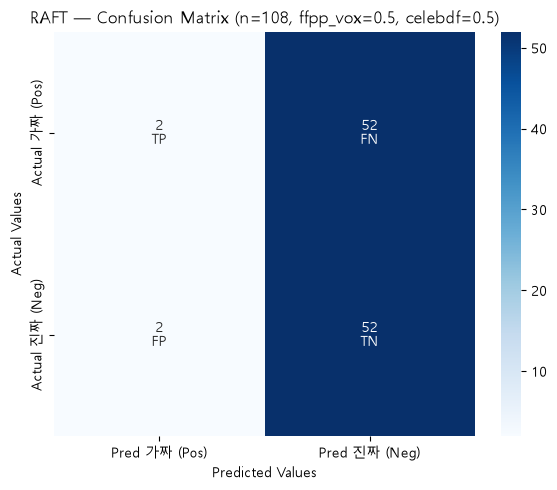

CM (rows=fake,real):
 [[ 2 52]
 [ 2 52]]
              precision    recall  f1-score   support

        fake      0.500     0.037     0.069        54
        real      0.500     0.963     0.658        54

    accuracy                          0.500       108
   macro avg      0.500     0.500     0.364       108
weighted avg      0.500     0.500     0.364       108



In [5]:
def plot_team_cm(y_true, y_pred, title: str, out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_TEAM)
    tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    annot = np.array([[f"{tp}\nTP", f"{fn}\nFN"], [f"{fp}\nFP", f"{tn}\nTN"]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 가짜 (Pos)", "Pred 진짜 (Neg)"],
        yticklabels=["Actual 가짜 (Pos)", "Actual 진짜 (Neg)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Actual Values")
    ax.set_title(title)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return cm


thr_note = ", ".join(f"{k}={thr_by_profile[k]}" for k in active_profiles)
cm_all = plot_team_cm(
    y_true,
    y_pred,
    title=f"RAFT — Confusion Matrix (n={len(items_all)}, {thr_note})",
    out_path=OUT_DIR / f"cm_raft_{len(items_all)}_combined.png",
)
print("CM (rows=fake,real):\n", cm_all)
print(classification_report(y_true, y_pred, labels=LABELS_TEAM, digits=3))


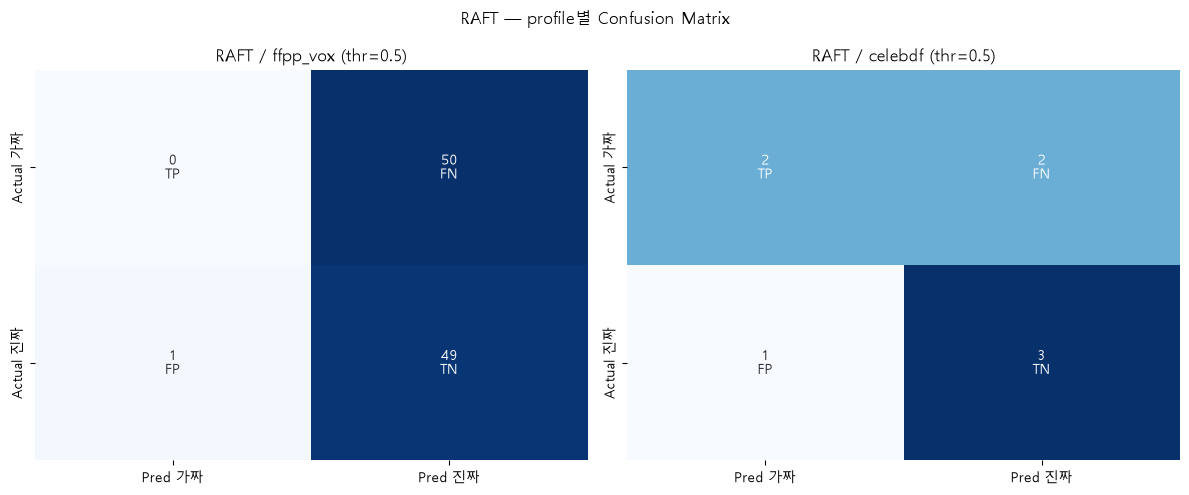

saved C:\sw_study\finalpjt\ai\docs\notebooks\output\raft-cm\cm_raft_108_by_profile.png


In [6]:
if len(active_profiles) >= 2:
    fig, axes = plt.subplots(1, len(active_profiles), figsize=(6 * len(active_profiles), 5))
    if len(active_profiles) == 1:
        axes = [axes]
    for ax, key in zip(axes, active_profiles):
        items = items_by_profile[key]
        thr = thr_by_profile[key]
        yt = [it["ground_truth_label"] for it in items]
        yp = pred_labels(items, thr)
        cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
        annot = np.array(
            [[f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"], [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]]
        )
        sns.heatmap(
            cm,
            annot=annot,
            fmt="",
            cmap="Blues",
            xticklabels=["Pred 가짜", "Pred 진짜"],
            yticklabels=["Actual 가짜", "Actual 진짜"],
            ax=ax,
            cbar=False,
        )
        ax.set_title(f"RAFT / {key} (thr={thr})")
    fig.suptitle("RAFT — profile별 Confusion Matrix")
    fig.tight_layout()
    split_path = OUT_DIR / f"cm_raft_{len(items_all)}_by_profile.png"
    fig.savefig(split_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {split_path}")


## ROC Curve

- **Positive = fake(1)**, score = `fake_score` / `motion_anomaly_score`
- **AUC**: 1에 가까울수록 좋음. 점선 = 랜덤(0.5). ● = 프로필 threshold 지점.


saved C:\sw_study\finalpjt\ai\docs\notebooks\output\raft-cm\roc_raft_108_combined.png


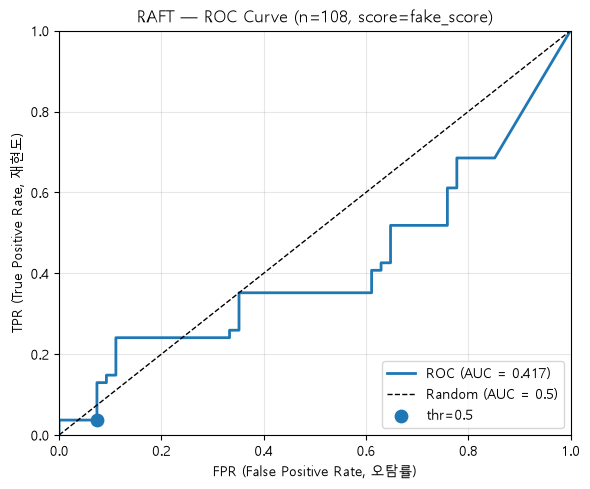

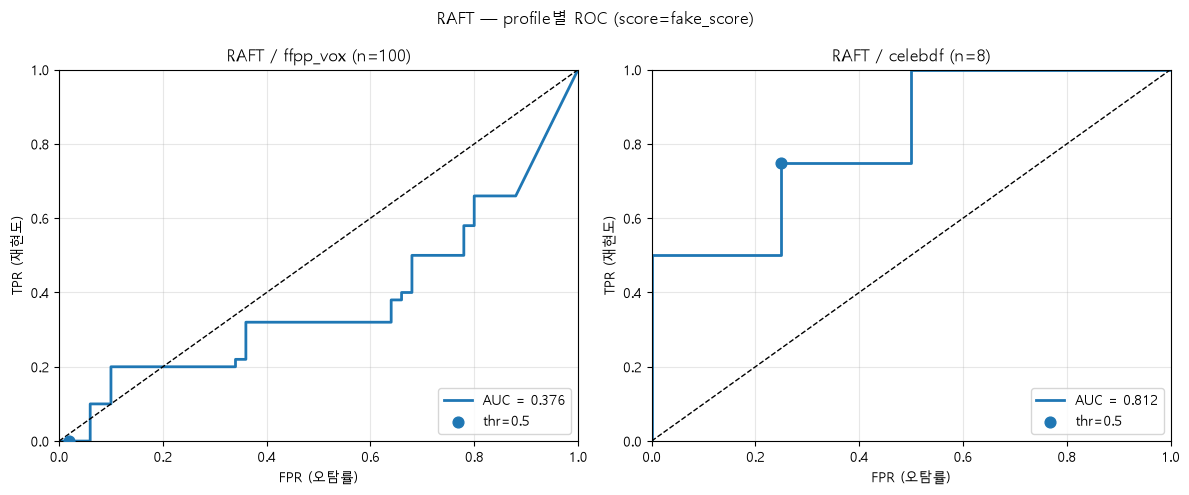

saved C:\sw_study\finalpjt\ai\docs\notebooks\output\raft-cm\roc_raft_108_by_profile.png


,구분,AUC,n
0,108 combined,0.4174,108
1,ffpp_vox,0.3756,100
2,celebdf,0.8125,8


In [7]:
from sklearn.metrics import roc_curve, auc
from IPython.display import display

SCORE_FIELD = "fake_score"
MODEL_LABEL = "RAFT"


def items_to_roc_arrays(items) -> tuple[np.ndarray, np.ndarray]:
    y_list: list[int] = []
    s_list: list[float] = []
    skipped = 0
    for it in items:
        score = _item_score(it)
        if score is None:
            skipped += 1
            continue
        y_list.append(1 if it["ground_truth_label"] == "fake" else 0)
        s_list.append(score)
    if skipped:
        print(f"ROC: skipped {skipped} item(s) with no score")
    return np.array(y_list), np.array(s_list)


def plot_roc_single(items, title: str, out_path: Path | None = None, thr: float = 0.5) -> float:
    y, s = items_to_roc_arrays(items)
    fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - thr)))
        ax.scatter(fpr[idx], tpr[idx], s=80, zorder=5, label=f"thr={thr}")
    ax.set_xlabel("FPR (False Positive Rate, 오탐률)")
    ax.set_ylabel("TPR (True Positive Rate, 재현도)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return roc_auc


n_all = len(items_all)
auc_all = plot_roc_single(
    items_all,
    f"{MODEL_LABEL} — ROC Curve (n={n_all}, score={SCORE_FIELD})",
    OUT_DIR / f"roc_raft_{n_all}_combined.png",
    thr=0.5,
)

if len(active_profiles) >= 2:
    fig, axes = plt.subplots(1, len(active_profiles), figsize=(6 * len(active_profiles), 5))
    if len(active_profiles) == 1:
        axes = [axes]
    auc_rows = []
    for ax, key in zip(axes, active_profiles):
        items = items_by_profile[key]
        thr = thr_by_profile[key]
        y, s = items_to_roc_arrays(items)
        fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
        a = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {a:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        if len(thresholds) > 0:
            idx = int(np.argmin(np.abs(thresholds - thr)))
            ax.scatter(fpr[idx], tpr[idx], s=60, zorder=5, label=f"thr={thr}")
        ax.set_xlabel("FPR (오탐률)")
        ax.set_ylabel("TPR (재현도)")
        ax.set_title(f"{MODEL_LABEL} / {key} (n={len(items)})")
        ax.legend(loc="lower right")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        auc_rows.append({"구분": key, "AUC": f"{a:.4f}", "n": len(items)})
    fig.suptitle(f"{MODEL_LABEL} — profile별 ROC (score={SCORE_FIELD})")
    fig.tight_layout()
    split_roc = OUT_DIR / f"roc_raft_{n_all}_by_profile.png"
    fig.savefig(split_roc, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {split_roc}")
else:
    auc_rows = []
    for key in active_profiles:
        items = items_by_profile[key]
        thr = thr_by_profile[key]
        y, s = items_to_roc_arrays(items)
        fpr, tpr, _ = roc_curve(y, s, pos_label=1)
        auc_rows.append({"구분": key, "AUC": f"{auc(fpr, tpr):.4f}", "n": len(items)})

display(
    pd.DataFrame(
        [{"구분": f"{n_all} combined", "AUC": f"{auc_all:.4f}", "n": n_all}] + auc_rows
    )
)


## 분류 지표 추출 (Accuracy · Precision · Recall · F1)

**Positive = 가짜(`fake`)** 기준:

| 지표 | 공식 |
|------|------|
| Accuracy(정확도) | (TP + TN) / (TP + FN + FP + TN) |
| Precision(정밀도) | TP / (TP + FP) |
| Recall(재현도) | TP / (TP + FN) |
| F1-Score(조화평균) | 2 × P × R / (P + R) |


In [ ]:
from IPython.display import Markdown, display


def metrics_from_cm(cm: np.ndarray) -> dict:
    tp, fn, fp, tn = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    total = tp + fn + fp + tn
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "TP": tp, "FN": fn, "FP": fp, "TN": tn, "n": total,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "acc_num": tp + tn, "acc_den": total,
        "prec_num": tp, "prec_den": tp + fp,
        "rec_num": tp, "rec_den": tp + fn,
        "f1_num": 2 * tp, "f1_den": 2 * tp + fp + fn,
    }


def metrics_table(m: dict) -> pd.DataFrame:
    rows = [
        {"지표": "Accuracy(정확도)", "분자": f"TP + TN = {m['TP']} + {m['TN']} = {m['acc_num']}", "분모": f"TP + FN + FP + TN = {m['n']}", "수식": f"{m['acc_num']} / {m['acc_den']}", "값": f"{m['accuracy']:.4f}", "백분율": f"{m['accuracy'] * 100:.2f}%"},
        {"지표": "Precision(정밀도)", "분자": f"TP = {m['prec_num']}", "분모": f"TP + FP = {m['TP']} + {m['FP']} = {m['prec_den']}", "수식": f"{m['prec_num']} / {m['prec_den']}", "값": f"{m['precision']:.4f}", "백분율": f"{m['precision'] * 100:.2f}%"},
        {"지표": "Recall(재현도)", "분자": f"TP = {m['rec_num']}", "분모": f"TP + FN = {m['TP']} + {m['FN']} = {m['rec_den']}", "수식": f"{m['rec_num']} / {m['rec_den']}", "값": f"{m['recall']:.4f}", "백분율": f"{m['recall'] * 100:.2f}%"},
        {"지표": "F1-Score(조화평균)", "분자": f"2 × TP = 2 × {m['TP']} = {m['f1_num']}", "분모": f"2×TP + FP + FN = {m['f1_den']}", "수식": f"{m['f1_num']} / {m['f1_den']}", "값": f"{m['f1']:.4f}", "백분율": f"{m['f1'] * 100:.2f}%"},
    ]
    return pd.DataFrame(rows)


def display_metrics_block(label: str, yt, yp) -> dict:
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    m = metrics_from_cm(cm)
    tp, fn, fp, tn = m["TP"], m["FN"], m["FP"], m["TN"]

    display(Markdown(f"### {label}  \n**n = {m['n']}** · Positive = fake (가짜)"))
    display(Markdown(
        f'''
| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = {tp}** | FN = {fn} |
| **Actual real** | FP = {fp} | **TN = {tn}** |
'''
    ))
    display(metrics_table(m))
    display(Markdown(
        f'''
**LaTeX 형태**

$$
\\text{{Accuracy(정확도)}} = \\frac{{TP + TN}}{{TP + FN + FP + TN}}
= \\frac{{{tp} + {tn}}}{{{m['n']}}}
= \\frac{{{m['acc_num']}}}{{{m['acc_den']}}}
= {m['accuracy']:.4f}
$$

$$
\\text{{Precision(정밀도)}} = \\frac{{TP}}{{TP + FP}}
= \\frac{{{tp}}}{{{tp} + {fp}}}
= \\frac{{{m['prec_num']}}}{{{m['prec_den']}}}
= {m['precision']:.4f}
$$

$$
\\text{{Recall(재현도)}} = \\frac{{TP}}{{TP + FN}}
= \\frac{{{tp}}}{{{tp} + {fn}}}
= \\frac{{{m['rec_num']}}}{{{m['rec_den']}}}
= {m['recall']:.4f}
$$

$$
\\text{{F1-Score(조화평균)}} = \\frac{{2 \\times \\text{{Precision}} \\times \\text{{Recall}}}}{{\\text{{Precision}} + \\text{{Recall}}}}
= \\frac{{{m['f1_num']}}}{{{m['f1_den']}}}
= {m['f1']:.4f}
$$
'''
    ))
    return m


m_all = display_metrics_block(f"RAFT combined (n={len(items_all)})", y_true, y_pred)

summary_rows = [{
    "구분": f"{len(items_all)} combined",
    "threshold": thr_note,
    "TP": m_all["TP"], "FN": m_all["FN"], "FP": m_all["FP"], "TN": m_all["TN"],
    "Accuracy(정확도)": f"{m_all['acc_num']}/{m_all['acc_den']} = {m_all['accuracy']:.3f}",
    "Precision(정밀도)": f"{m_all['prec_num']}/{m_all['prec_den']} = {m_all['precision']:.3f}",
    "Recall(재현도)": f"{m_all['rec_num']}/{m_all['rec_den']} = {m_all['recall']:.3f}",
    "F1-Score(조화평균)": f"{m_all['f1_num']}/{m_all['f1_den']} = {m_all['f1']:.3f}",
}]

for key in active_profiles:
    items = items_by_profile[key]
    thr = thr_by_profile[key]
    yt = [it["ground_truth_label"] for it in items]
    yp = pred_labels(items, thr)
    m = display_metrics_block(f"RAFT · {key} (thr={thr})", yt, yp)
    summary_rows.append({
        "구분": key,
        "threshold": str(thr),
        "TP": m["TP"], "FN": m["FN"], "FP": m["FP"], "TN": m["TN"],
        "Accuracy(정확도)": f"{m['acc_num']}/{m['acc_den']} = {m['accuracy']:.3f}",
        "Precision(정밀도)": f"{m['prec_num']}/{m['prec_den']} = {m['precision']:.3f}",
        "Recall(재현도)": f"{m['rec_num']}/{m['rec_den']} = {m['recall']:.3f}",
        "F1-Score(조화평균)": f"{m['f1_num']}/{m['f1_den']} = {m['f1']:.3f}",
    })

display(Markdown("### 전체 요약"))
display(pd.DataFrame(summary_rows))
